# ML Week 12: Neural Networks

With the basics of vectors and matrices we learned last week, we already have the skills to build a neural network!

We will start with a simple one:

* Input Layer = 4 neurons
* Hidden Layer 1 = 4 neurons
* Hidden Layer 2 = 4 neurons
* Output Layer = 4 neurons

<div>
<img src="./NN1.png" width="1000"/>
</div>
Source: https://alexlenail.me/NN-SVG/

Each layer will be a vector (where each number is a node).

The weights between the nodes will be a matrix:

$$\begin{bmatrix} w_{11} & w_{12} & w_{13} & w_{14} \\ w_{21} & w_{22} & w_{23} & w_{24} \\ w_{31} & w_{32} & w_{33} & w_{34} \\ w_{41} & w_{42} & w_{43} & w_{44}\end{bmatrix}$$

In this matrix, each entry represents the "weight" of a connection. For example $w_{31}$ is the strenght of the connection from the 3rd node to the 1st node.

### Let's try connecting the first layer!

In [12]:
import numpy as np
import scipy as sp

In [13]:
# Starting with some generic input (the input layer)

input = np.array([[1,2,3,4]])
print(input)

[[1 2 3 4]]


In [14]:
# Now let's make some random weights. In modern neural networks weights are usually initialized to be small and between -1 and +1
weights = np.random.uniform(-1,1,(4,4))
print(weights)

# Note: In fact, there are slightly more clever ways of intitializing weights (ie "He Initialization"), but we won't worry about that for simplicity

[[ 0.9760838   0.36266101 -0.62280481 -0.4010843 ]
 [-0.76167853 -0.06741842  0.31009767 -0.35550413]
 [ 0.71366023  0.03726288 -0.70085078 -0.68371229]
 [-0.0435712   0.77111185 -0.34135937  0.63478031]]


In [15]:
# Let's propogate the signal from the input to the first hidden layer
hidden_layer1 = input @ weights
print(hidden_layer1)

[[ 1.41942264  3.42406023 -3.47059927 -0.62410819]]


### Activation Functions

It turns out that networks built ONLY on repeated multiplication and addition are not very good at capturing more commplex behaviour.

Very early on it was realized that adding one extra step at each layer truly unlocks the power of neural networks.

This is adding what are called "Activation Functions".

There are many different versions, but now the industry standard is called "ReLU" which stands for "Rectified Linear Function".

This is actually super simple! For each hidden layer, before continuing on to the next one, set all negative neurons to zero.

In code, it is simply the super easy addition of one more line:

In [16]:
hidden_layer1 = input @ weights
hidden_layer1 = np.maximum(hidden_layer1,0) # ReLu Activation Function
print(hidden_layer1)

[[1.41942264 3.42406023 0.         0.        ]]


### Computing Multiple Layers

In [17]:
# We can also put the weights between multiple layers into a single matrix.
# This matrix has 3 layers of 4x4 weight values:

weights = np.random.uniform(-1, 1, (3,4,4))

In [18]:
weights

array([[[-0.52819373, -0.36419764,  0.81600772,  0.62890673],
        [-0.21748867,  0.32433475, -0.79543084, -0.03858299],
        [-0.98810838, -0.43778174, -0.74082921, -0.65227613],
        [-0.13504237, -0.28699389, -0.6343294 , -0.71208108]],

       [[ 0.12052492,  0.80186821,  0.21855985,  0.43848866],
        [ 0.77320862, -0.64259051,  0.12574388,  0.81521642],
        [ 0.32357245, -0.00323558,  0.75362258, -0.99701027],
        [-0.1541883 ,  0.56874422,  0.69945518, -0.33692673]],

       [[-0.14500165, -0.52503561, -0.43351791,  0.93854137],
        [ 0.63637408,  0.99822765, -0.31716827,  0.39605949],
        [-0.30306927, -0.78030167, -0.68155075,  0.87213379],
        [-0.38239954,  0.90618277,  0.88626361,  0.42759912]]])

In [19]:
# We do exactly the same thing, but this time we need to specify which section (or "slice") of the 3D matrix we want to use

hidden_layer1 = input @ weights[0]  # We do that here with the index on the end
hidden_layer1 = np.maximum(hidden_layer1,0)
hidden_layer1

array([[0., 0., 0., 0.]])

In [20]:
# We can also put this into a loop where each iteration chooses the next batch of weights:

for i in range(weights.shape[0]):
    hidden_layer = input @ weights[i]
    hidden_layer = np.maximum(hidden_layer,0)
    input = hidden_layer
    print(hidden_layer)

[[0. 0. 0. 0.]]
[[0. 0. 0. 0.]]
[[0. 0. 0. 0.]]


### But how do we choose the selected class from the final layer?

The final layer is just a bunch of numbers. How do we decide which class has been selected?

For this, we first use something called "softmax". This changes the numbers into probabilities of the input belonging to each of the classes.

So if the final layer is $[0.1, 0.6, 0.1, 0.2]$ then this means there is a 10% chance of the input belonging to class 1, a 60% input of the input belonging to class 2, a 10% chance of the input belonging to class 3, and a 20% chance of the input belonging to class 4.

Lastly, to choose the most probable class we use the "argmax" (maximum argumnet) method:

In [21]:
for i in range(weights.shape[0]):
    hidden_layer = input @ weights[i]  # Multiply (dot product) with the weights
    hidden_layer = np.maximum(hidden_layer,0)  # ReLU
    input = hidden_layer  # Set the current layer as input to the next one and repeat
    print(hidden_layer)

output = sp.special.softmax(hidden_layer)
np.argmax(output)

[[0. 0. 0. 0.]]
[[0. 0. 0. 0.]]
[[0. 0. 0. 0.]]


np.int64(0)

In [ ]:
# We can also put this into a function:

def forward_pass(input, weights):
    for i in range(weights.shape[0]):
        input = input @ weights[i,:,:]
        input = np.maximum(input,0)  # This time we just overwrite input repeatedly as we don't really need an extra "hidden_layer" variable. More efficient.
    
    output = sp.special.softmax(input)  # Note: in general relu should not be applied to the last layer (which we did in the loop), but this time we can let it slide
    output_class = np.argmax(output)
    
    return output_class

In [23]:
# Running the function with many different inputs we see different inputs are classified as different classes
# Note that it's normal to have inbalanced classes - we randomly initialized the weights.

for i in range(50):
    print(forward_pass(np.random.uniform(-1,1,(1,4)), weights))  # Run the forward pass with some random input and the weights from before.

3
3
3
0
3
3
3
0
3
3
3
3
0
3
3
3
3
0
3
1
3
3
0
3
3
3
3
3
3
3
3
3
3
0
3
3
3
0
3
3
3
3
0
3
0
3
3
3
1
3


### This simplest form of Artificial Neural Network (ANN) is called a Multi-Layer Perceptron (MLP).

### Okay...but these weights are random. How do we actually train them?

By giving a network a bunch of input (X) for which you know the expected classes (y) you can repeatedly adjust the weights based on how "good or bad" the guessed output was. The adjustments are propagated from the last layer to the first layer "backwards", hence this training is called "back propagation" (or "backprop").

In fact, the math behind backprop is not that bad, but understanding it perfectly is probably too much for this course.

# Exercises

### Exercise 1

Multi-Layer Perceptrons are easy to set up with scikit-learn, even if they do have a lot of adjustable things (hyperparametres).

As with previous ML methods, MLPs can be used for either Classification (MLPClassifier) or Regression (MLPRegressor).

Below we read in the Wanyika data we used last semester. Let's try to build a regressor to predict site date from the available tabular features.

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# load site data
df = pd.read_csv('./Wanyika_cleaned.csv')

# set the y (the label we want to predict)
y = df['Mean Chronology  (Calibrated BP - 1950) ']

# set the X (the features we want the algorithm to learn from)
X = df.drop(columns=['Mean Chronology  (Calibrated BP - 1950) '])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [10]:
# MLP = Multi-Layer Perceptron

from sklearn.neural_network import MLPRegressor
mlp_reg = MLPRegressor(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=(5, 5, 2), max_iter=10000)  # lbfgs = Limited-memory Broyden–Fletcher–Goldfarb–Shanno

In [11]:
mlp_reg.fit(X_train,y_train)

,loss,'squared_error'
,hidden_layer_sizes,"(5, ...)"
,activation,'relu'
,solver,'lbfgs'
,alpha,1e-05
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,10000
,shuffle,True


In [12]:
pred = mlp_reg.predict(X_test)
mean_absolute_error(y_test, pred)

874.3996504406982

In [ ]:
# It's important to use cross validation to know the proper score.
# The best I am getting is sub-800 years MAE with a single relatively small layer (see hidden_layer_sizes)
# This is an indication that the data set is likely not a good fit for an ANN. RF is a better choice

from sklearn.model_selection import KFold, cross_val_score

# set up the classifier 
mlp_reg = MLPRegressor(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=(15), max_iter=10000)

# set the number of folds
k_folds = KFold(n_splits = 4, shuffle=True)

# calculate the scores
scores = cross_val_score(mlp_reg, X, y, cv = k_folds, scoring="neg_mean_absolute_error")

# print the scores
print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("Standard deviation: ", scores.std())

Cross Validation Scores:  [-802.24555992 -816.53125487 -766.04752945 -734.52813015]
Average CV Score:  -779.8381185950934
Standard deviation:  31.98302314562757


In [ ]:
# Deeper more complex networks are making the performance worse.

from sklearn.model_selection import KFold, cross_val_score

# set up the classifier 
mlp_reg = MLPRegressor(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=(20, 20, 2), max_iter=10000)

# set the number of folds
k_folds = KFold(n_splits = 4, shuffle=True)

# calculate the scores
scores = cross_val_score(mlp_reg, X, y, cv = k_folds, scoring="neg_mean_absolute_error")

# print the scores
print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("Standard deviation: ", scores.std())

Cross Validation Scores:  [-678.15528721 -956.23378375 -791.91919523 -860.6057842 ]
Average CV Score:  -821.7285125974844
Standard deviation:  101.37181149553034


### Exercise 2

The test network we built had input, hidden, and output layers all with 4 neurons.

This makes them very clean to code, but not very realistic. In general we have larger hidden layers, and smaller output layers.

Let's build a more realistic network that takes in 5 input features, has 3 hidden layers each with 10 neurons, and finally classifies between 3 classes (3 output neurons).

The network will look something like this:

<div>
<img src="./NN2.png" width="1000"/>
</div>
Source: https://alexlenail.me/NN-SVG/

In [ ]:
def forward_pass(input, input_weights, hidden_weights, output_weights):

    input = input @ input_weights  # New: A first layer to get the input to the right shape for the hidden layers
    input = np.maximum(input,0)
    
    for i in range(hidden_weights.shape[0]):
        input = input @ hidden_weights[i,:,:]
        input = np.maximum(input,0)
    
    output = input @ output_weights  # New: A final layer to get the output of the hidden layer to the right shape for the output layer
    output = sp.special.softmax(output)
    output_class = np.argmax(output)
    
    return output_class

In [31]:
input_weights = np.random.uniform(-1, 1, (5,10))
hidden_weights = np.random.uniform(-1, 1, (2,10,10))
output_weights = np.random.uniform(-1, 1, (10,3))

for i in range(50):
    print(forward_pass(np.random.uniform(-1,1,(1,5)), input_weights, hidden_weights, output_weights))  # Run the forward pass with some random input and the weights from before.

2
0
2
0
2
1
0
2
0
2
0
2
0
2
2
0
0
0
0
0
0
2
0
2
2
0
2
0
0
2
0
2
2
2
0
2
2
2
0
2
2
2
0
2
2
2
0
2
0
2


### Exercise 3

In general, ANN are not well suited to handle image data. More advanced networks such as CNN (coming next class!) are now the dominant standard.

However, early computer vision applications did feed image data directly into ANN.

Let's see how this was done!

Imagine an $8\times8$ array "M":

In [32]:
M = np.random.rand(8,8)

This array can be thought of as representing an $8\times8$ pixel image, which we can view with matplotlib:

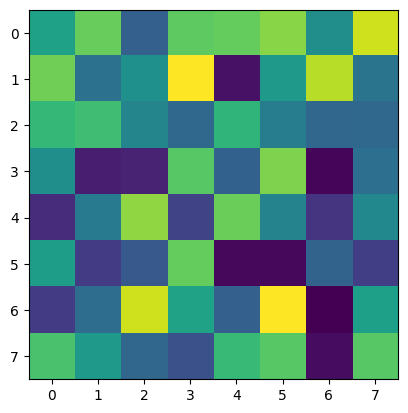

In [33]:
import matplotlib.pyplot as plt

plt.imshow(M)

For this exercise, look online into how to "unravel" the matrix into a 1D vector, and then adjust your above ANN's first layer (and first set of weights) to handle that data input.

In [ ]:
input = M.ravel()  # Unravel the matrix

input_weights = np.random.uniform(-1, 1, (len(input),10))  # Adjust the input weights (shape = (64,10))

forward_pass(input, input_weights, hidden_weights, output_weights)  # Run a forward pass with the new input and weights

np.int64(2)

Although this can work for basic computer vision problems, it is not optimal as we lose any information about the relationship between pixels and their neighbours.

In the 1980s CNN's were able to solve this problem and paved the way for the modern computer vision techniques we use today.